# Notebook Conclusion

1. Three regression models were developed to predict taxi trip duration before ride initiation:
   - Linear Regression
   - XGBoost
   - LightGBM

2. Linear Regression established a baseline benchmark for evaluating advanced ensemble methods.

3. Model-specific preprocessing pipelines were implemented to ensure appropriate treatment of different feature types.

4. XGBoost and LightGBM effectively captured non-linear relationships and interactions within the data.

5. Validation metrics were used to compare model performance and identify the most suitable candidate model.

6. The selected model demonstrated strong generalization performance on the independent test dataset.

7. Feature importance analysis provided valuable insights into the factors influencing trip duration predictions.

8. The selected model will undergo hyperparameter tuning in the subsequent notebook to further optimize predictive performance.

# Model Development

## Objective

The objective of this notebook is to develop and evaluate machine learning models to predict **taxi trip duration before ride initiation** using historical trip characteristics and engineered features.

The modeling process aims to:

- Establish a baseline performance using a simple regression model.
- Develop advanced ensemble models capable of capturing complex relationships within the data.
- Compare model performance using appropriate regression evaluation metrics.
- Select the most suitable model for further optimization and deployment.

The models evaluated in this notebook include:

1. **Linear Regression** – used as a baseline model to establish an initial performance benchmark.
2. **XGBoost Regressor** – a gradient boosting algorithm known for strong predictive performance on structured data.
3. **LightGBM Regressor** – an efficient gradient boosting framework optimized for large-scale datasets.

The final selected model will be carried forward to the hyperparameter tuning and deployment stages of the project.

---

# Import Required Libraries

The following libraries are imported for:

- Data manipulation and preprocessing
- Model development
- Performance evaluation
- Visualization of model results

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Splitting
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

# Models
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Load Processed Dataset

The processed dataset generated from previous preprocessing and feature engineering stages is loaded for model development.

This dataset contains cleaned records and engineered features that are available **before ride initiation**, ensuring that no information leakage occurs during training.

In [3]:
df = pd.read_parquet(
    "/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/USECASE2_Trip_Fare_Forecasting/data/feature_engineered_taxi_data.parquet"
)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (3499962, 12)


,tpep_pickup_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,trip_duration,pickup_hour,pickup_dayofweek,pickup_day,is_weekend,is_rush_hour,Location_Pair
0,2026-01-01 00:54:04,1.0,0.97,239,238,5.550000,0,3,1,0,0,239_238
1,2026-01-01 00:15:22,4.0,5.58,142,209,42.800000,0,3,1,0,0,142_209
2,2026-01-01 00:47:11,2.0,2.33,144,137,13.600000,0,3,1,0,0,144_137
3,2026-01-01 00:17:54,1.0,1.30,142,50,10.633333,0,3,1,0,0,142_50
4,2026-01-01 00:34:14,1.0,5.34,161,45,37.733333,0,3,1,0,0,161_45


# Dataset Overview

Before model development, it is important to verify:

- Dataset dimensions
- Feature availability
- Presence of missing values
- Data types of the variables

This step ensures that the modeling pipeline receives clean and valid input data.

In [4]:
# Shape of dataset
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData Types:")
display(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum())

Rows: 3499962
Columns: 12

Data Types:


tpep_pickup_datetime    datetime64[us]
passenger_count                float64
trip_distance                  float64
PULocationID                     int32
DOLocationID                     int32
trip_duration                  float64
pickup_hour                      int32
pickup_dayofweek                 int32
pickup_day                       int32
is_weekend                       int64
is_rush_hour                     int64
Location_Pair                   object
dtype: object


Missing Values:


tpep_pickup_datetime    0
passenger_count         0
trip_distance           0
PULocationID            0
DOLocationID            0
trip_duration           0
pickup_hour             0
pickup_dayofweek        0
pickup_day              0
is_weekend              0
is_rush_hour            0
Location_Pair           0
dtype: int64

# Define Features and Target Variable

The target variable for this use case is:

- **trip_duration** → Total duration of the taxi trip in minutes.

Features used for prediction include:

### Numerical Features
- passenger_count
- trip_distance
- pickup_hour
- pickup_dayofweek
- pickup_day

### Categorical Features
- PULocationID
- DOLocationID
- Location_Pair

### Binary Features
- is_weekend
- is_rush_hour

The original pickup timestamp is excluded because relevant temporal information has already been extracted during feature engineering.

In [5]:
TARGET = "trip_duration"

numerical_features = [
    "passenger_count",
    "trip_distance",
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_day"
]

categorical_features = [
    "PULocationID",
    "DOLocationID",
    "Location_Pair"
]

binary_features = [
    "is_weekend",
    "is_rush_hour"
]

FEATURES = (
    numerical_features +
    categorical_features +
    binary_features
)

X = df[FEATURES]

y = df[TARGET]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (3499962, 10)
Target Shape: (3499962,)


# Why not use tpep_pickup_datetime?

Because:

Raw datetime values cannot be directly used by machine learning models. We extract meaningful temporal features from them instead.

# Feature Selection Rationale

The selected features were chosen based on domain knowledge and insights obtained during exploratory data analysis.

- **Trip Distance:** Identified as the strongest predictor of trip duration.
- **Pickup Time Features:** Capture traffic patterns and rush-hour effects.
- **Location Features:** Represent spatial travel behavior across NYC zones.
- **Passenger Count:** Included to account for potential variations in trip dynamics.
- **Weekend and Rush Hour Indicators:** Capture temporal behavioral patterns affecting travel time.

These features collectively provide temporal, spatial, and operational information required to predict trip duration before ride initiation.

# Train-Validation-Test Split

To ensure robust model evaluation and prevent information leakage during model development, the dataset is divided into three subsets:

- **Training Set (70%)**
  - Used to train machine learning models.

- **Validation Set (15%)**
  - Used for model selection, hyperparameter tuning, and performance monitoring during development.

- **Testing Set (15%)**
  - Reserved for the final unbiased evaluation of the selected model.

Using a separate validation set ensures that the test set remains completely unseen until the final assessment stage, providing a more realistic estimate of model generalization performance.

In [7]:
# First split: Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Second split: Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("Dataset Split Summary")
print("-" * 40)

print(f"Training Set:   {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation Set: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Testing Set:    {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

Dataset Split Summary
----------------------------------------
Training Set:   2,449,973 samples (70.0%)
Validation Set: 524,994 samples (15.0%)
Testing Set:    524,995 samples (15.0%)


## Why Use a Validation Set?

A validation set is introduced to support model development without contaminating the test set.

It allows:

- Hyperparameter tuning
- Model comparison and selection
- Early stopping for boosting algorithms
- Monitoring potential overfitting

By reserving the test set exclusively for final evaluation, the reported performance metrics provide a more reliable estimate of real-world model performance.

# Model-Specific Preprocessing Pipelines

Different machine learning algorithms have different preprocessing requirements.

## Linear Regression

Linear Regression is sensitive to feature scales. Therefore:

- Numerical features are standardized using `StandardScaler`.
- Categorical features are transformed using `OneHotEncoder`.
- Binary features are retained without transformation.

## XGBoost and LightGBM

Tree-based ensemble methods are invariant to feature scaling. Therefore:

- Numerical features are retained in their original form.
- Categorical features are transformed using `OneHotEncoder`.
- Binary features are retained without transformation.

Using model-specific preprocessing pipelines ensures that each algorithm receives the most appropriate input representation, leading to improved model performance and computational efficiency.

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

# Preprocessing for Linear Regression
preprocessor_lr = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "bin",
            "passthrough",
            binary_features
        )
    ]
)

# Preprocessing for Tree-Based Models
preprocessor_tree = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "bin",
            "passthrough",
            binary_features
        )
    ]
)

# Linear Regression (Baseline Model)

Linear Regression is selected as the baseline model to establish an initial performance benchmark.

## Why Linear Regression?

- Provides a simple and interpretable starting point.
- Serves as a reference for evaluating more advanced models.
- Enables quantification of performance improvements achieved by ensemble methods.
- Computationally efficient even with large datasets.

Although exploratory data analysis revealed non-linear relationships and the presence of outliers, establishing a baseline model is considered a best practice in machine learning workflows.

The objective of this model is not necessarily to achieve the highest predictive performance but rather to provide a benchmark against which more sophisticated algorithms can be compared.

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

lr_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_lr
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

# Training Linear Regression

The Linear Regression model is trained using the training dataset.

The validation dataset will be used for model comparison and subsequent model selection.

In [11]:
lr_pipeline.fit(
    X_train,
    y_train
)

lr_val_pred = lr_pipeline.predict(
    X_val
)

print("Linear Regression training completed.")

Linear Regression training completed.


# Baseline Model Evaluation

The Linear Regression model is evaluated on the validation dataset using:

- **Mean Absolute Error (MAE):** Average absolute prediction error.
- **Root Mean Squared Error (RMSE):** Penalizes larger prediction errors more heavily.
- **R² Score:** Measures the proportion of variance explained by the model.

These metrics establish the baseline performance for comparison with advanced ensemble methods.

In [12]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

lr_mae = mean_absolute_error(
    y_val,
    lr_val_pred
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        lr_val_pred
    )
)

lr_r2 = r2_score(
    y_val,
    lr_val_pred
)

print("Linear Regression Validation Performance")
print("-" * 45)
print(f"MAE  : {lr_mae:.2f}")
print(f"RMSE : {lr_rmse:.2f}")
print(f"R²   : {lr_r2:.4f}")

Linear Regression Validation Performance
---------------------------------------------
MAE  : 4.59
RMSE : 7.44
R²   : 0.7070


# XGBoost Regressor

XGBoost is selected as the primary advanced model due to its strong predictive performance on structured tabular datasets.

## Why XGBoost?

- Captures complex non-linear relationships.
- Automatically models feature interactions.
- Incorporates regularization techniques to reduce overfitting.
- Demonstrates strong performance on real-world regression tasks.
- Handles large datasets efficiently.

Based on insights obtained during exploratory data analysis, XGBoost is expected to outperform the baseline Linear Regression model.

In [13]:
from xgboost import XGBRegressor

xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_tree
        ),
        (
            "model",
            XGBRegressor(
                objective="reg:squarederror",
                n_estimators=100,
                learning_rate=0.1,
                max_depth=6,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Training XGBoost

The XGBoost model is trained using the training dataset.

Validation performance is assessed to compare against the baseline model and guide future hyperparameter tuning.

In [14]:
xgb_pipeline.fit(
    X_train,
    y_train
)

xgb_val_pred = xgb_pipeline.predict(
    X_val
)

print("XGBoost training completed.")

XGBoost training completed.


In [15]:
xgb_mae = mean_absolute_error(
    y_val,
    xgb_val_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        xgb_val_pred
    )
)

xgb_r2 = r2_score(
    y_val,
    xgb_val_pred
)

print("XGBoost Validation Performance")
print("-" * 40)
print(f"MAE  : {xgb_mae:.2f}")
print(f"RMSE : {xgb_rmse:.2f}")
print(f"R²   : {xgb_r2:.4f}")

XGBoost Validation Performance
----------------------------------------
MAE  : 3.94
RMSE : 6.66
R²   : 0.7651


In [16]:
train_pred = xgb_pipeline.predict(X_train)
val_pred = xgb_pipeline.predict(X_val)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

print(f"Train RMSE: {train_rmse:.2f}")
print(f"Validation RMSE: {val_rmse:.2f}")

Train RMSE: 6.67
Validation RMSE: 6.66


# LightGBM Regressor

LightGBM (Light Gradient Boosting Machine) is included as an alternative gradient boosting algorithm designed for efficient training on large datasets.

## Why LightGBM?

- Efficient training and lower memory consumption.
- Handles large-scale datasets effectively.
- Captures complex non-linear relationships and feature interactions.
- Often achieves competitive predictive performance compared to XGBoost.
- Uses a leaf-wise tree growth strategy that can improve accuracy.

Including LightGBM enables comparison between two state-of-the-art boosting frameworks and helps identify the most suitable model for the trip duration prediction task.

In [17]:
from lightgbm import LGBMRegressor
from sklearn.pipeline import Pipeline

lgbm_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_tree
        ),
        (
            "model",
            LGBMRegressor(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=6,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Training LightGBM

The LightGBM model is trained using the training dataset and evaluated on the validation dataset.

The validation performance is used to compare LightGBM against the baseline Linear Regression and XGBoost models.

In [18]:
lgbm_pipeline.fit(
    X_train,
    y_train
)

lgbm_val_pred = lgbm_pipeline.predict(
    X_val
)

print("LightGBM training completed.")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.104147 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 33331
[LightGBM] [Info] Number of data points in the train set: 2449973, number of used features: 16508
[LightGBM] [Info] Start training from score 17.105693
LightGBM training completed.


# LightGBM Evaluation

The LightGBM model is evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The same evaluation metrics are used across all models to ensure fair comparison.

In [19]:
lgbm_mae = mean_absolute_error(
    y_val,
    lgbm_val_pred
)

lgbm_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        lgbm_val_pred
    )
)

lgbm_r2 = r2_score(
    y_val,
    lgbm_val_pred
)

print("LightGBM Validation Performance")
print("-" * 40)
print(f"MAE  : {lgbm_mae:.2f}")
print(f"RMSE : {lgbm_rmse:.2f}")
print(f"R²   : {lgbm_r2:.4f}")

LightGBM Validation Performance
----------------------------------------
MAE  : 3.98
RMSE : 6.71
R²   : 0.7619


# Model Comparison

The developed models are compared using validation performance metrics.

Evaluation metrics include:

- **MAE:** Average absolute prediction error.
- **RMSE:** Penalizes larger prediction errors and serves as the primary model selection metric.
- **R² Score:** Indicates the proportion of variance explained by the model.

The model with the lowest RMSE and strong generalization performance will be selected for further optimization.

In [20]:
comparison_df = pd.DataFrame(
    {
        "Model": [
            "Linear Regression",
            "XGBoost",
            "LightGBM"
        ],
        "MAE": [
            lr_mae,
            xgb_mae,
            lgbm_mae
        ],
        "RMSE": [
            lr_rmse,
            xgb_rmse,
            lgbm_rmse
        ],
        "R²": [
            lr_r2,
            xgb_r2,
            lgbm_r2
        ]
    }
)

comparison_df = comparison_df.sort_values(
    by="RMSE"
)

comparison_df

,Model,MAE,RMSE,R²
1,XGBoost,3.941454,6.659988,0.765076
2,LightGBM,3.975817,6.705183,0.761876
0,Linear Regression,4.585593,7.438008,0.706982


# Model Performance Visualization

Visual comparison of model performance facilitates easier interpretation of differences in predictive accuracy.

Lower values of MAE and RMSE indicate better performance, while higher R² values indicate improved explanatory capability.

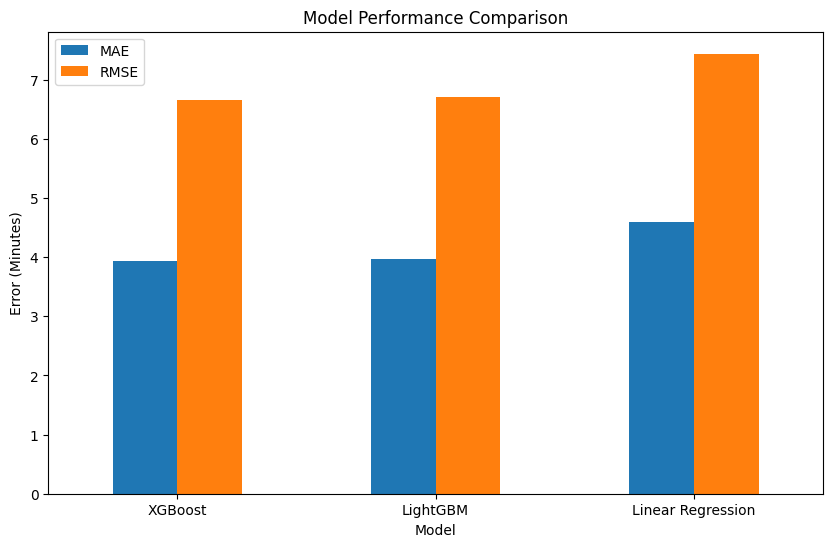

In [21]:
comparison_df.plot(
    x="Model",
    y=["MAE", "RMSE"],
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Model Performance Comparison"
)

plt.ylabel(
    "Error (Minutes)"
)

plt.xticks(
    rotation=0
)

plt.show()

# Final Model Selection

The model demonstrating the best validation performance based on RMSE and generalization capability is selected for final evaluation.

RMSE is prioritized because:

- It penalizes large prediction errors more heavily.
- Large duration prediction errors can significantly impact customer experience and operational planning.
- It provides an interpretable metric in the same unit as the target variable (minutes).

The selected model will undergo final evaluation using the independent test dataset.

In [22]:
best_model_name = comparison_df.iloc[0]["Model"]

print(f"Selected Model: {best_model_name}")

Selected Model: XGBoost


# Final Evaluation on Test Dataset

After selecting the best-performing model using validation data, its performance is assessed on the independent test dataset.

The test set provides an unbiased estimate of how the model is expected to perform on unseen real-world data.

In [23]:
if best_model_name == "Linear Regression":
    final_model = lr_pipeline

elif best_model_name == "XGBoost":
    final_model = xgb_pipeline

else:
    final_model = lgbm_pipeline

test_pred = final_model.predict(
    X_test
)

test_mae = mean_absolute_error(
    y_test,
    test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_pred
    )
)

test_r2 = r2_score(
    y_test,
    test_pred
)

print("Final Test Performance")
print("-" * 35)
print(f"MAE  : {test_mae:.2f}")
print(f"RMSE : {test_rmse:.2f}")
print(f"R²   : {test_r2:.4f}")

Final Test Performance
-----------------------------------
MAE  : 3.97
RMSE : 6.76
R²   : 0.7612


# Feature Importance Analysis

Feature importance analysis provides insight into which variables contribute most to trip duration predictions.

Understanding influential features enhances model interpretability and helps validate domain knowledge derived from exploratory data analysis.

Feature importance is extracted from the selected tree-based model.

In [24]:
if best_model_name == "XGBoost":

    feature_importance = (
        final_model.named_steps["model"]
        .feature_importances_
    )

elif best_model_name == "LightGBM":

    feature_importance = (
        final_model.named_steps["model"]
        .feature_importances_
    )

In [25]:
feature_names = (
    final_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

importance_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance": feature_importance
    }
)

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
1,num__trip_distance,0.164810
399,cat__DOLocationID_138,0.044171
525,cat__DOLocationID_265,0.024225
266,cat__DOLocationID_1,0.022841
393,cat__DOLocationID_132,0.017762
138,cat__PULocationID_138,0.017628
2,num__pickup_hour,0.015474
4,num__pickup_day,0.014453
3,num__pickup_dayofweek,0.013856
132,cat__PULocationID_132,0.013344


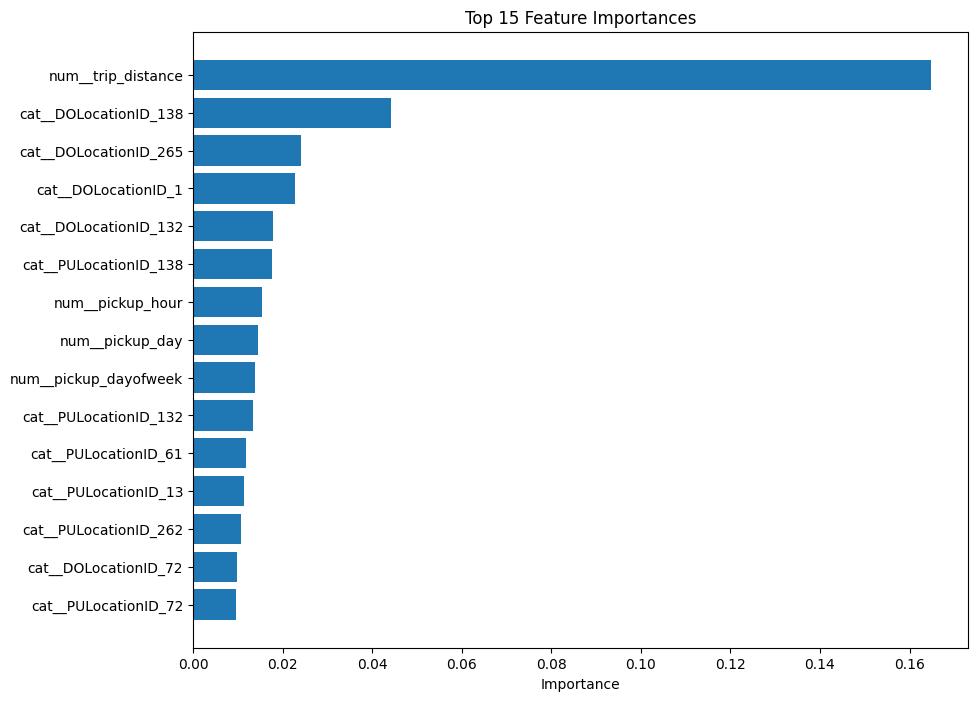

In [26]:
top_features = importance_df.head(15)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top 15 Feature Importances"
)

plt.xlabel(
    "Importance"
)

plt.show()

In [27]:
# Training predictions
xgb_train_pred = xgb_pipeline.predict(X_train)

# Validation predictions
xgb_val_pred = xgb_pipeline.predict(X_val)

# Test predictions
xgb_test_pred = xgb_pipeline.predict(X_test)

# Calculate RMSE
xgb_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        xgb_train_pred
    )
)

xgb_val_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        xgb_val_pred
    )
)

xgb_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_test_pred
    )
)

performance_df = pd.DataFrame(
    {
        "Dataset": [
            "Train",
            "Validation",
            "Test"
        ],
        "RMSE": [
            xgb_train_rmse,
            xgb_val_rmse,
            xgb_test_rmse
        ]
    }
)

performance_df

,Dataset,RMSE
0,Train,6.666690
1,Validation,6.659988
2,Test,6.760582


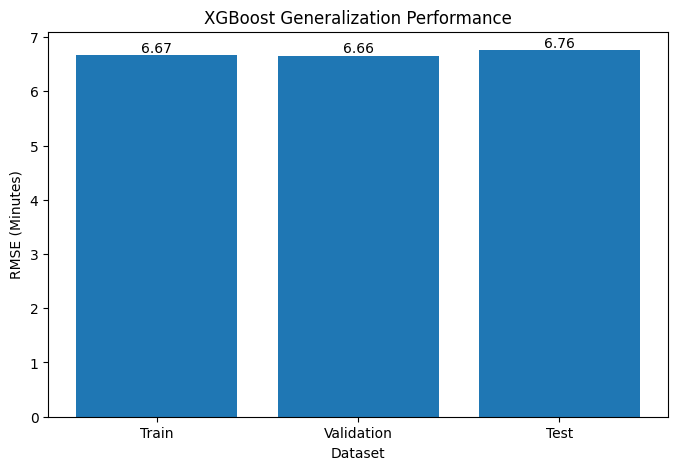

In [29]:
plt.figure(figsize=(8, 5))

plt.bar(
    performance_df["Dataset"],
    performance_df["RMSE"]
)

plt.title(
    "XGBoost Generalization Performance"
)

plt.ylabel(
    "RMSE (Minutes)"
)

plt.xlabel(
    "Dataset"
)

# Add values above bars
for index, value in enumerate(performance_df["RMSE"]):
    plt.text(
        index,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.show()

### Observation

- The RMSE values across the training, validation, and test datasets are highly consistent.
- The absence of a substantial performance gap indicates that the XGBoost model generalizes well to unseen data.
- No evidence of overfitting is observed, as validation and test errors remain comparable to training error.
- The model successfully captures underlying trip duration patterns without memorizing the training data.

### Conclusion

The XGBoost model demonstrates strong generalization capability and can be considered a reliable candidate for further optimization through hyperparameter tuning.

In [31]:
y.describe()

count    3.499962e+06
mean     1.711191e+01
std      1.375306e+01
min      1.666667e-02
25%      8.333333e+00
50%      1.353333e+01
75%      2.133333e+01
max      1.799667e+02
Name: trip_duration, dtype: float64

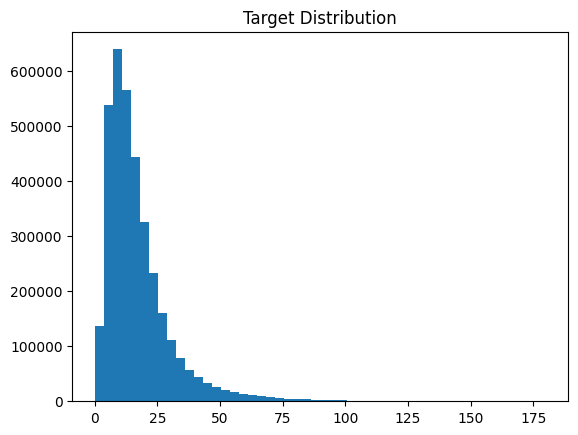

In [32]:
import matplotlib.pyplot as plt

plt.hist(y, bins=50)
plt.title("Target Distribution")
plt.show()